## EDA danych ChEMBL

In [44]:
!pip -q install pyspark chembl-downloader

from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import chembl_downloader
import pandas as pd
import numpy as np
from matplotlib.ticker import PercentFormatter
from pyspark.sql import SparkSession



Pobranie ChEMBL SQLite:

In [45]:
sqlite_path = chembl_downloader.download_extract_sqlite()
print(sqlite_path)


/root/.data/chembl/36/chembl_36.db


Uruchamienie SparkSession i konfiguracja sterowników JDBC dla SQLite, żeby czytać tabele ChEMBL bezpośrednio do DataFrame’ów Sparka:

In [46]:

spark = (
    SparkSession.builder
    .appName("chembl-eda")
    .master("local[*]")
    .config("spark.jars.packages", "org.xerial:sqlite-jdbc:3.51.1.0")
    .getOrCreate()
)

print("Spark OK:", spark.version)
print("packages:", spark.sparkContext.getConf().get("spark.jars.packages"))


Spark OK: 4.0.2
packages: org.xerial:sqlite-jdbc:3.51.1.0


# Wstępna eksploracja danych

### Wczytanie `activities` z ChEMBL (SQLite → Spark przez JDBC)

Ustawiam połączenie JDBC do pliku SQLite, definiuję helper `t()` do wczytywania tabel i wybieram tylko potrzebne kolumny.  
Tutaj ładuję tabelę `activities` i robię szybki podgląd pierwszych wierszy.


In [47]:
jdbc_url = f"jdbc:sqlite:{sqlite_path}"
props = {"driver": "org.sqlite.JDBC"}

def t(name, cols=None, custom_schema=None):
    reader = (spark.read.format("jdbc")
              .option("url", jdbc_url)
              .option("dbtable", name)
              .option("driver", "org.sqlite.JDBC"))
    if custom_schema:
        reader = reader.option("customSchema", custom_schema)

    df = reader.load()
    return df.select(*cols) if cols else df


activities = t(
    "activities",
    cols=[
        "activity_id","assay_id","molregno",
        "standard_type","standard_relation","standard_units",
        "standard_value","pchembl_value"
    ],
    custom_schema="""
        activity_id BIGINT,
        assay_id BIGINT,
        molregno BIGINT,
        standard_value DOUBLE,
        pchembl_value DOUBLE
    """
)

activities.printSchema()
activities.show(5)


root
 |-- activity_id: long (nullable = true)
 |-- assay_id: long (nullable = true)
 |-- molregno: long (nullable = true)
 |-- standard_type: string (nullable = true)
 |-- standard_relation: string (nullable = true)
 |-- standard_units: string (nullable = true)
 |-- standard_value: double (nullable = true)
 |-- pchembl_value: double (nullable = true)

+-----------+--------+--------+-------------+-----------------+--------------+--------------+-------------+
|activity_id|assay_id|molregno|standard_type|standard_relation|standard_units|standard_value|pchembl_value|
+-----------+--------+--------+-------------+-----------------+--------------+--------------+-------------+
|      31863|   54505|  180094|         IC50|                >|            nM|      100000.0|         NULL|
|      31864|   83907|  182268|         IC50|                =|            nM|        2500.0|          5.6|
|      31865|   88152|  182268|         IC50|                >|            nM|       50000.0|         NULL

Ujednolicenie nazw kolumn (np. tid → target_id):

In [48]:
# w nowszych wersjach chembl nazwy kolumn moga sie roznic
assays0 = t("assays")
assays = (assays0
          .withColumnRenamed("tid", "target_id")
          .select("assay_id", "target_id", "assay_type", "confidence_score"))

targets0 = t("target_dictionary")

targets = (targets0
           .withColumnRenamed("tid", "target_id")
           .withColumnRenamed("chembl_id", "target_chembl_id")
           .select("target_id", "target_chembl_id", "pref_name", "target_type", "organism"))

structures = t("compound_structures", ["molregno","canonical_smiles","standard_inchi_key"])

In [49]:
print("activities", activities.count())
print("assays", assays.count())
print("targets", targets.count())
print("structures", structures.count())


activities 24267312
assays 1890749
targets 17803
structures 2854815


In [50]:
def quick_profile(df, name):
    print(f"\n== {name} ==")
    print("rows:", df.count(), "cols:", len(df.columns))
    df.printSchema()

quick_profile(activities, "activities")
quick_profile(assays, "assays")
quick_profile(targets, "targets")
quick_profile(structures, "structures")


== activities ==
rows: 24267312 cols: 8
root
 |-- activity_id: long (nullable = true)
 |-- assay_id: long (nullable = true)
 |-- molregno: long (nullable = true)
 |-- standard_type: string (nullable = true)
 |-- standard_relation: string (nullable = true)
 |-- standard_units: string (nullable = true)
 |-- standard_value: double (nullable = true)
 |-- pchembl_value: double (nullable = true)


== assays ==
rows: 1890749 cols: 4
root
 |-- assay_id: decimal(20,0) (nullable = true)
 |-- target_id: decimal(20,0) (nullable = true)
 |-- assay_type: string (nullable = true)
 |-- confidence_score: integer (nullable = true)


== targets ==
rows: 17803 cols: 5
root
 |-- target_id: decimal(20,0) (nullable = true)
 |-- target_chembl_id: string (nullable = true)
 |-- pref_name: string (nullable = true)
 |-- target_type: string (nullable = true)
 |-- organism: string (nullable = true)


== structures ==
rows: 2854815 cols: 3
root
 |-- molregno: decimal(20,0) (nullable = true)
 |-- canonical_smiles: s

Biorąc pod uwagę, że decimal(20, 0) jest dość słaby wydajnościowo to warto rozważyć castowanie na long.

In [51]:
activities_c = (activities
    .select(
        F.col("activity_id").cast("long").alias("activity_id"),
        F.col("assay_id").cast("long").alias("assay_id"),
        F.col("molregno").cast("long").alias("molregno"),
        "standard_type","standard_relation","standard_units",
        F.col("standard_value").cast("double").alias("standard_value"),
        F.col("pchembl_value").cast("double").alias("pchembl_value"),
    )
)

assays_c = assays.select(
    F.col("assay_id").cast("long").alias("assay_id"),
    F.col("target_id").cast("long").alias("target_id"),
    "assay_type","confidence_score"
)

targets_c = targets.select(
    F.col("target_id").cast("long").alias("target_id"),
    "target_chembl_id","pref_name","target_type","organism"
)

structures_c = structures.select(
    F.col("molregno").cast("long").alias("molregno"),
    "canonical_smiles","standard_inchi_key"
)


Braki danych:

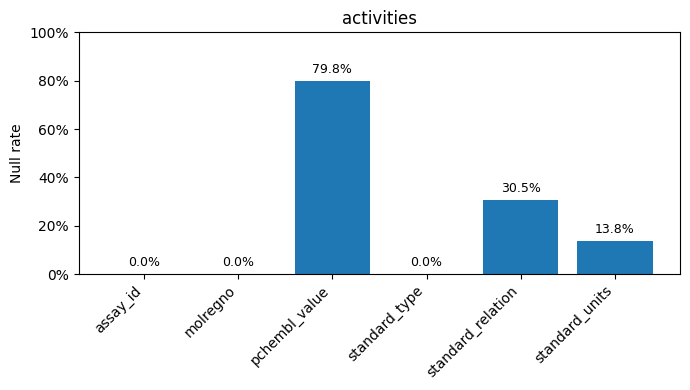

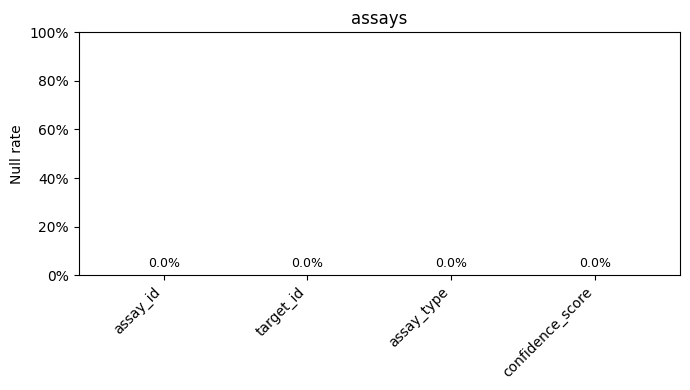

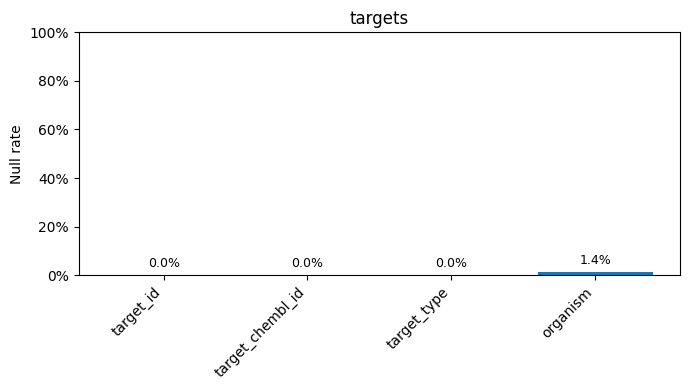

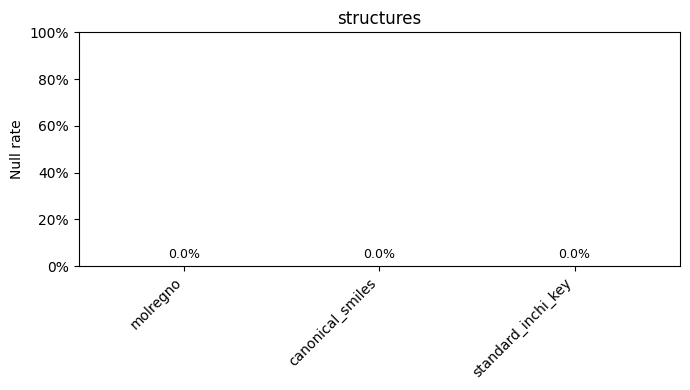

In [52]:
def null_rates(df, cols):
    agg_exprs = [F.count(F.lit(1)).alias("_n")] + [
        F.sum(F.col(c).isNull().cast("int")).alias(c) for c in cols
    ]
    row = df.agg(*agg_exprs).collect()[0].asDict()
    n = row.pop("_n")
    return {c: (row[c] / n if n else 0.0) for c in cols}

def plot_null_rates(rates, title=None):
    cols = list(rates.keys())
    vals = [rates[c] for c in cols]

    plt.figure(figsize=(max(7, 0.9 * len(cols)), 4))
    bars = plt.bar(cols, vals)

    ax = plt.gca()
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    plt.ylim(0, 1)
    plt.ylabel("Null rate")
    plt.xticks(rotation=45, ha="right")
    if title:
        plt.title(title)

    for i, v in enumerate(vals):
        ax.text(i, min(v + 0.02, 0.98), f"{v:.1%}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()

plot_null_rates(
    null_rates(activities, ["assay_id","molregno","pchembl_value","standard_type","standard_relation","standard_units"]),
    "activities"
)

plot_null_rates(
    null_rates(assays, ["assay_id","target_id","assay_type","confidence_score"]),
    "assays"
)

plot_null_rates(
    null_rates(targets, ["target_id","target_chembl_id","target_type","organism"]),
    "targets"
)

plot_null_rates(
    null_rates(structures, ["molregno","canonical_smiles","standard_inchi_key"]),
    "structures"
)

`activities` ma bardzo dużo braków w `pchembl_value` (ok. 80%) oraz istotne braki w `standard_relation` (ok. 30%) i `standard_units` (ok. 14%), Target ma niewielkie braki w kolumnie `organism`.

Rozkłady kategorii na próbce 10%.

In [53]:
act_s = activities_c.sample(False, 0.10, seed=42).cache()
_ = act_s.count()  # materializacja cache

act_s.groupBy("standard_type").count().orderBy(F.desc("count")).show(30, truncate=False)
act_s.groupBy("standard_units").count().orderBy(F.desc("count")).show(30, truncate=False)
act_s.groupBy("standard_relation").count().orderBy(F.desc("count")).show(30, truncate=False)

+---------------------+------+
|standard_type        |count |
+---------------------+------+
|Potency              |449008|
|IC50                 |354617|
|GI50                 |263868|
|Inhibition           |159751|
|Activity             |135232|
|Percent Effect       |132582|
|Ki                   |88136 |
|k_off                |82706 |
|kon                  |82427 |
|MIC                  |77894 |
|EC50                 |60241 |
|INHIBITION           |33757 |
|AC50                 |28072 |
|Kd                   |21181 |
|Z score              |14840 |
|Ratio IC50           |14535 |
|GI                   |13086 |
|Tissue Severity Score|12560 |
|Ratio                |12318 |
|ED50                 |10691 |
|CC50                 |10286 |
|IZ                   |9668  |
|T1/2                 |8987  |
|CL                   |7866  |
|FC                   |7438  |
|Residual Activity    |7199  |
|Stability            |5935  |
|Solubility           |5791  |
|LC50                 |5302  |
|TGI    

Podstawowe statystyki

In [55]:
act_focus = (activities_c
    .filter(F.col("standard_relation") == "=")
    .filter(F.col("standard_type").isin("IC50","Ki","Kd","EC50"))
    .filter(F.col("standard_units").isin("pM","nM","uM","mM","M"))
)

act_focus.select("standard_value","pchembl_value").describe().show()

+-------+--------------------+------------------+
|summary|      standard_value|     pchembl_value|
+-------+--------------------+------------------+
|  count|             3638663|           3508645|
|   mean|3.299740818763516E21|6.5346292486480095|
| stddev|5.294551205699761E24|1.4086857204086363|
|    min|           -100000.0|              0.85|
|    max|              1.0E28|             12.46|
+-------+--------------------+------------------+



In [58]:
for col in ["standard_value", "pchembl_value"]:
    q = act_focus.approxQuantile(col, [0.01, 0.5, 0.99], 0.001)
    print(col, "p01/median/p99 =", q)


standard_value p01/median/p99 = [0.13, 440.0, 619000.0]
pchembl_value p01/median/p99 = [4.1, 6.43, 9.82]


In [57]:
assays_c.select("confidence_score").describe().show()
assays_c.groupBy("confidence_score").count().orderBy(F.desc("count")).show(30)


+-------+------------------+
|summary|  confidence_score|
+-------+------------------+
|  count|           1890749|
|   mean|3.1021489367441157|
| stddev|3.6177678195048344|
|    min|                 0|
|    max|                 9|
+-------+------------------+

+----------------+------+
|confidence_score| count|
+----------------+------+
|               1|961280|
|               9|422850|
|               0|335567|
|               8| 90442|
|               5| 26390|
|               3| 20531|
|               7| 16982|
|               4|  8682|
|               2|  5094|
|               6|  2931|
+----------------+------+



Rozkład danych na próbce 20%

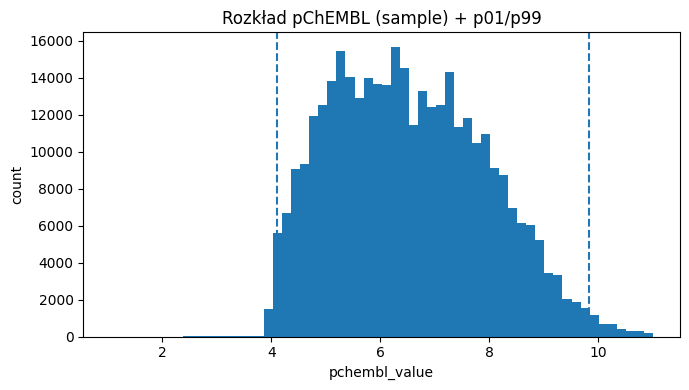

In [61]:
sample_frac = 0.1
pdf = (act_focus
       .select("standard_value","pchembl_value","standard_units","standard_type")
       .sample(False, sample_frac, seed=42)
       .toPandas())

p01, p99 = act_focus.approxQuantile("pchembl_value", [0.01, 0.99], 0.001)

vals = pdf["pchembl_value"].dropna()

plt.figure(figsize=(7,4))
plt.hist(vals, bins=60)
plt.axvline(p01, linestyle="--")
plt.axvline(p99, linestyle="--")
plt.title("Rozkład pChEMBL (sample) + p01/p99")
plt.xlabel("pchembl_value")
plt.ylabel("count")
plt.tight_layout()
plt.show()


Większość danych znajduje się między p01 a p99.

Duplikaty

Sprawdzanie, czy klucze są unikalne.

In [63]:
assays_c.groupBy("assay_id").count().orderBy(F.desc("count")).show(10)
targets_c.groupBy("target_id").count().orderBy(F.desc("count")).show(10)
structures_c.groupBy("molregno").count().orderBy(F.desc("count")).show(10)


+--------+-----+
|assay_id|count|
+--------+-----+
|      61|    1|
|      26|    1|
|     303|    1|
|      29|    1|
|    1309|    1|
|     474|    1|
|    1812|    1|
|     964|    1|
|    1813|    1|
|    1677|    1|
+--------+-----+
only showing top 10 rows
+---------+-----+
|target_id|count|
+---------+-----+
|       29|    1|
|    10871|    1|
|    10959|    1|
|    11567|    1|
|    11619|    1|
|    11938|    1|
|    12568|    1|
|    17048|    1|
|    19907|    1|
|    30025|    1|
+---------+-----+
only showing top 10 rows
+--------+-----+
|molregno|count|
+--------+-----+
|      26|    1|
|      61|    1|
|      29|    1|
|     303|    1|
|     474|    1|
|    1309|    1|
|     964|    1|
|    1813|    1|
|    1697|    1|
|    1968|    1|
+--------+-----+
only showing top 10 rows


`assays.assay_id`, `targets.target_id` i `structures.molregno` wydają się być unikalnymi kluczami.

Duplikaty pomiarów, sprawdzamy na próbce 20%, czy jest dużo powtórzeń tych samych pomiarów.

In [65]:
act_s = act_focus.sample(False, 0.20, seed=42).cache()
_ = act_s.count()

dups = (act_s
  .groupBy("molregno","assay_id","standard_type")
  .agg(F.count("*").alias("n"))
  .orderBy(F.desc("n"))
)
dups.show(20, truncate=False)


+--------+--------+-------------+---+
|molregno|assay_id|standard_type|n  |
+--------+--------+-------------+---+
|2052417 |2484304 |IC50         |15 |
|2052417 |2484303 |IC50         |12 |
|2881828 |2381837 |IC50         |11 |
|2052417 |2484305 |IC50         |9  |
|3112954 |2592462 |IC50         |9  |
|2128490 |2484305 |IC50         |8  |
|2184765 |1641534 |IC50         |7  |
|3112954 |2592463 |IC50         |7  |
|2184765 |1641533 |IC50         |6  |
|3150693 |2592505 |IC50         |6  |
|3210959 |2589759 |Ki           |6  |
|415966  |2595833 |IC50         |5  |
|1797633 |217263  |Ki           |5  |
|2137588 |2589532 |IC50         |5  |
|3245784 |2592901 |IC50         |5  |
|3175919 |2592505 |IC50         |5  |
|1285392 |1641870 |IC50         |5  |
|3193762 |2593529 |EC50         |4  |
|2212513 |1698432 |Ki           |4  |
|2968132 |2593127 |Ki           |4  |
+--------+--------+-------------+---+
only showing top 20 rows


Jest wiele rekordów dla tej samej kombinacji (molregno, assay_id, standard_type).